In [1]:
# MCS underflow/overflow check for exiting muons -- reviewer question (London)
#
# SPINE's mcs_fit (spine/utils/mcs.py) bounds the MLE kinetic-energy search to
# lower_bound=10.0 MeV, upper_bound=100000.0 MeV (100 GeV) by default. This
# script checks, on the full nominal MC sample, what fraction of exiting
# (uncontained) muons in the selected sample pile up at or near these bounds.

import uproot
import numpy as np

DATA_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)

LOWER_BOUND = 10.0       # MeV, SPINE mcs_fit default lower_bound
UPPER_BOUND = 100000.0   # MeV, SPINE mcs_fit default upper_bound

f = uproot.open(DATA_FILE)
t = f["events/full/selected"]

arr = t.arrays(
    ["reco_leading_muon_containment", "reco_leading_muon_mcs_ke"],
    library="np",
)
containment = arr["reco_leading_muon_containment"]
mcs_ke = arr["reco_leading_muon_mcs_ke"]

exiting_mask = containment == 0
exiting_ke = mcs_ke[exiting_mask]
n_exiting = len(exiting_ke)

print(f"Total selected entries: {len(mcs_ke)}")
print(f"Exiting (uncontained) muons: {n_exiting}")
print()

print("MCS KE distribution (exiting muons):")
print(f"  min = {np.nanmin(exiting_ke):.3f} MeV")
print(f"  max = {np.nanmax(exiting_ke):.3f} MeV")
pct = np.nanpercentile(exiting_ke, [0, 1, 5, 50, 95, 99, 100])
print(f"  percentiles [0,1,5,50,95,99,100] = {pct}")
print()

# Exact pile-up at the MLE bounds
n_at_lower = np.sum(exiting_ke == LOWER_BOUND)
n_at_upper = np.sum(exiting_ke == UPPER_BOUND)
print(f"Exactly at lower bound ({LOWER_BOUND} MeV): "
      f"{n_at_lower} ({100 * n_at_lower / n_exiting:.3f}%)")
print(f"Exactly at upper bound ({UPPER_BOUND} MeV): "
      f"{n_at_upper} ({100 * n_at_upper / n_exiting:.3f}%)")
print()

# Check whether the pile-up is a hard spike at the boundary or a smooth
# approach -- compare counts at a few thresholds below the upper bound.
for thresh in [1000, 5000, 10000, 50000, 90000, 99999]:
    n_above = np.sum(exiting_ke >= thresh)
    print(f"  >= {thresh:>6} MeV: {n_above:6d} ({100 * n_above / n_exiting:.3f}%)")

n_between = np.sum((exiting_ke >= 90000) & (exiting_ke < UPPER_BOUND))
print(f"\nEvents in [90000, {UPPER_BOUND}) MeV, i.e. near but not at the "
      f"upper bound: {n_between}")

# For reference: same check on contained muons (MCS is computed for all
# tracks by default in SPINE's MCSEnergyProcessor, even though the analysis
# uses range-based momentum for contained muons instead of MCS).
contained_ke = mcs_ke[~exiting_mask]
n_contained = len(contained_ke)
n_at_upper_contained = np.sum(contained_ke == UPPER_BOUND)
print(f"\n[Reference only, not used in the analysis] Contained muons at "
      f"upper bound: {n_at_upper_contained} of {n_contained} "
      f"({100 * n_at_upper_contained / n_contained:.3f}%)")

Total selected entries: 98983
Exiting (uncontained) muons: 69119

MCS KE distribution (exiting muons):
  min = 143.452 MeV
  max = 100000.000 MeV
  percentiles [0,1,5,50,95,99,100] = [   143.45193481    183.23565063    277.86413574    927.85467529
   3737.00917969 100000.         100000.        ]

Exactly at lower bound (10.0 MeV): 0 (0.000%)
Exactly at upper bound (100000.0 MeV): 2205 (3.190%)

  >=   1000 MeV:  31342 (45.345%)
  >=   5000 MeV:   2843 (4.113%)
  >=  10000 MeV:   2342 (3.388%)
  >=  50000 MeV:   2210 (3.197%)
  >=  90000 MeV:   2206 (3.192%)
  >=  99999 MeV:   2205 (3.190%)

Events in [90000, 100000.0) MeV, i.e. near but not at the upper bound: 1

[Reference only, not used in the analysis] Contained muons at upper bound: 3 of 29864 (0.010%)


Category composition of selected tree:
  category 0.0: 12151
  category 1.0: 50656
  category 2.0: 946
  category 3.0: 19925
  category 4.0: 5244
  category 5.0: 296
  category 6.0: 6752
  category 7.0: 402
  category 8.0: 1009
  category 9.0: 1602

Selected true-signal exiting muons with valid truth: 61303

Bias/resolution of (p_reco - p_true)/p_true vs reco track length:
        bin [cm]       N  bias (median)  res (68%/2)
     50-70         3994          0.040        0.498
     70-100        6661         -0.002        0.453
    100-150       10286         -0.011        0.399
    150-200        8421         -0.034        0.364
    200-300       12844         -0.092        0.338
    300-450       10707         -0.150        0.304
    450-700        5231         -0.129        0.256


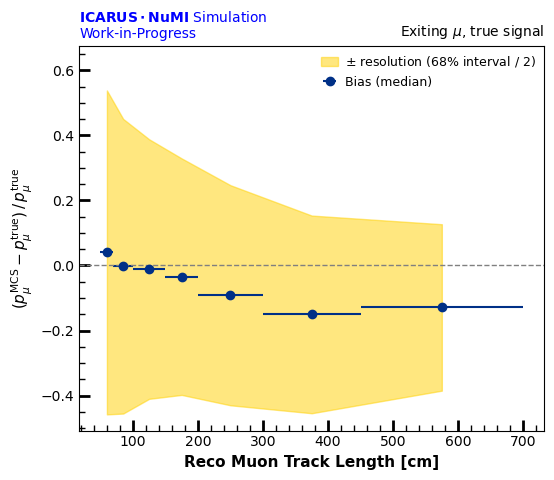

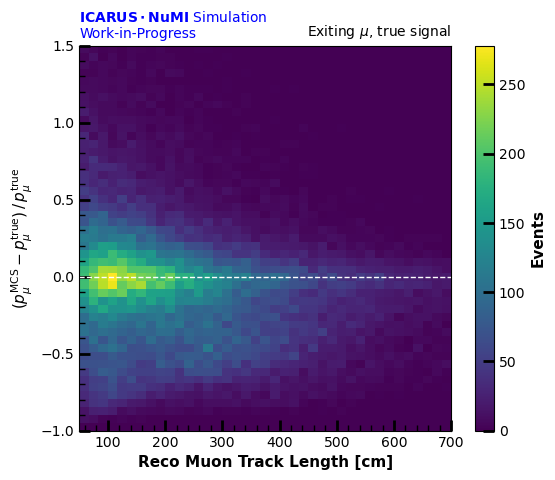


Threshold scan (threshold applied to EXITING muons only):
 L [cm]  exit ret.  total ret.     bias      res  dpT res [MeV/c]
     50      0.963       0.974   -0.064    0.358         116.1270
     60      0.933       0.954   -0.066    0.354         114.8197
     70      0.898       0.929   -0.070    0.348         113.1694
     80      0.862       0.904   -0.071    0.344         111.7644
    100      0.790       0.853   -0.078    0.336         108.2931
    120      0.719       0.804   -0.084    0.329         105.0720
    150      0.622       0.736   -0.098    0.317          98.7399


In [4]:
# MCS resolution for exiting muons vs. reco track length -- reviewer question (London)
#
# London: "Have you looked at the Emu^MCS resolution for exiting muons as a
# function of reco track length? You require ~50cm tracks for all muons, but
# may want to increase this threshold for exiting muons."
#
# Plan:
#   1. Take selected, true-signal, exiting muons from the nominal MC.
#   2. Bin them in reco track length and compute the fractional momentum
#      residual r = (p_reco - p_true)/p_true per bin. Bias = median(r),
#      resolution = half the central 68% interval, (q84 - q16)/2. Median and
#      percentiles are used instead of mean/std because the MCS residual has
#      long tails (including the 100 GeV MLE pile-up found in the cell above)
#      that would dominate a std.
#   3. Scan candidate length thresholds L and report, for each: exiting-muon
#      retention, total signal retention (contained muons unaffected), the
#      bias/resolution of the surviving exiting sample, and the dpT resolution
#      (un-normalized, reco - true, per London's comment on fractional
#      residuals for variables whose range covers 0).

import os
import uproot
import numpy as np
import matplotlib.pyplot as plt

DATA_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)

# ICARUS house colors
NAVY, GOLD, RED, GREEN = "#003087", "#FFD100", "#CC0000", "#2E8B57"

t = uproot.open(DATA_FILE)["events/full/selected"]
arr = t.arrays(
    [
        "true_category",
        "reco_leading_muon_containment",
        "reco_leading_muon_length",
        "reco_leading_muon_momentum",
        "true_leading_muon_momentum",
        "reco_dpT_lp",
        "true_dpT_lp_genie",
    ],
    library="np",
)

# True signal only: the residual is only meaningful when the truth match is a
# genuine 1muNp0pi signal event. Per the plotting TOML category_assignment,
# 'Signal' = {0, 3} and 'Signal QE' = {1, 4}, so signal = {0, 1, 3, 4}.
print("Category composition of selected tree:")
cats, counts = np.unique(arr["true_category"], return_counts=True)
for c, n in zip(cats, counts):
    print(f"  category {c}: {n}")

signal = np.isin(arr["true_category"], [0, 1, 3, 4])
exiting = arr["reco_leading_muon_containment"] == 0
valid = arr["true_leading_muon_momentum"] > 0

m = signal & exiting & valid
length = arr["reco_leading_muon_length"][m]
r = (arr["reco_leading_muon_momentum"][m] - arr["true_leading_muon_momentum"][m]) \
    / arr["true_leading_muon_momentum"][m]
print(f"\nSelected true-signal exiting muons with valid truth: {m.sum()}")

# ---------------------------------------------------------------
# 1) Bias and resolution in bins of reco track length
# ---------------------------------------------------------------
edges = np.array([50.0, 70.0, 100.0, 150.0, 200.0, 300.0, 450.0, 700.0])
centers = 0.5 * (edges[:-1] + edges[1:])
half_widths = 0.5 * np.diff(edges)

bias, res, nbin = [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    sel = (length >= lo) & (length < hi)
    ri = r[sel]
    nbin.append(sel.sum())
    if sel.sum() < 20:
        bias.append(np.nan)
        res.append(np.nan)
        continue
    q16, q50, q84 = np.percentile(ri, [15.865, 50.0, 84.135])
    bias.append(q50)
    res.append(0.5 * (q84 - q16))
bias, res, nbin = np.array(bias), np.array(res), np.array(nbin)

print("\nBias/resolution of (p_reco - p_true)/p_true vs reco track length:")
print(f"{'bin [cm]':>16} {'N':>7} {'bias (median)':>14} {'res (68%/2)':>12}")
for i in range(len(centers)):
    print(f"{edges[i]:>7.0f}-{edges[i+1]:<7.0f} {nbin[i]:>7d} "
          f"{bias[i]:>14.3f} {res[i]:>12.3f}")

# --- ICARUS house style helpers (same as NuMI_Flux.ipynb) ---
OUT_DIR = os.getcwd()
os.makedirs(os.path.join(OUT_DIR, "pdf"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "jpeg"), exist_ok=True)

def apply_icarus_style(ax, xlabel, ylabel, right_label):
    ax.set_xlabel(xlabel, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2,
                   direction="in")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily("sans-serif")
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
            r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\nWork-in-Progress",
            fontsize=10, color="blue", verticalalignment="bottom",
            fontfamily="sans-serif")
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02, right_label,
            fontsize=10, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

fig, ax = plt.subplots(figsize=(6, 5))
ax.fill_between(centers, bias - res, bias + res, color=GOLD, alpha=0.5,
                label=r"$\pm$ resolution (68% interval / 2)", step=None)
ax.errorbar(centers, bias, xerr=half_widths, fmt="o", color=NAVY,
            label="Bias (median)")
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 1.15)
ax.legend(fontsize=9, loc="upper right", ncol=1, framealpha=0.0,
          edgecolor="none", columnspacing=1.0, handlelength=1.4,
          handletextpad=0.5, borderaxespad=0.3)
apply_icarus_style(ax, "Reco Muon Track Length [cm]",
                   r"$(p_{\mu}^{\rm MCS} - p_{\mu}^{\rm true})\,/\,p_{\mu}^{\rm true}$",
                   r"Exiting $\mu$, true signal")
fig.savefig(os.path.join(OUT_DIR, "pdf/mcs_bias_resolution_vs_length.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUT_DIR, "jpeg/mcs_bias_resolution_vs_length.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()

# 2D view of the same information
fig, ax = plt.subplots(figsize=(6, 5))
xedges = np.linspace(50, 700, 40)
yedges = np.linspace(-1.0, 1.5, 50)
H, xe, ye = np.histogram2d(length, r, bins=[xedges, yedges])
pc = ax.pcolormesh(xe, ye, H.T, cmap="viridis")
cbar = fig.colorbar(pc, ax=ax)
cbar.set_label("Events", fontsize=11, fontweight="bold", fontfamily="sans-serif")
cbar.ax.tick_params(labelsize=10, size=8, width=2, direction="in")
ax.axhline(0.0, color="white", ls="--", lw=1)
apply_icarus_style(ax, "Reco Muon Track Length [cm]",
                   r"$(p_{\mu}^{\rm MCS} - p_{\mu}^{\rm true})\,/\,p_{\mu}^{\rm true}$",
                   r"Exiting $\mu$, true signal")
fig.savefig(os.path.join(OUT_DIR, "pdf/mcs_residual_vs_length_2d.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUT_DIR, "jpeg/mcs_residual_vs_length_2d.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()

# ---------------------------------------------------------------
# 2) Threshold scan: efficiency vs. bias/resolution vs. dpT resolution
# ---------------------------------------------------------------
# dpT resolution uses reco - true (un-normalized) since dpT approaches 0.
n_sig_total = (signal & valid).sum()
n_sig_contained = (signal & valid & ~exiting).sum()

dpt_reco_all = arr["reco_dpT_lp"][signal & valid]
dpt_true_all = arr["true_dpT_lp_genie"][signal & valid]
len_all = arr["reco_leading_muon_length"][signal & valid]
exit_all = (arr["reco_leading_muon_containment"] == 0)[signal & valid]

print("\nThreshold scan (threshold applied to EXITING muons only):")
print(f"{'L [cm]':>7} {'exit ret.':>10} {'total ret.':>11} "
      f"{'bias':>8} {'res':>8} {'dpT res [MeV/c]':>16}")
for L in [50, 60, 70, 80, 100, 120, 150]:
    keep_exit = length >= L
    exit_ret = keep_exit.sum() / len(length)
    total_ret = (n_sig_contained + keep_exit.sum()) / n_sig_total
    q16, q50, q84 = np.percentile(r[keep_exit], [15.865, 50.0, 84.135])
    keep_all = ~exit_all | (len_all >= L)
    d = dpt_reco_all[keep_all] - dpt_true_all[keep_all]
    d16, d84 = np.percentile(d, [15.865, 84.135])
    print(f"{L:>7d} {exit_ret:>10.3f} {total_ret:>11.3f} "
          f"{q50:>8.3f} {0.5*(q84-q16):>8.3f} {0.5*(d84-d16):>16.4f}")


All selected entries: 98983
Exiting leading proton (all selected): 3376 (3.41%)
True-signal selected w/ valid truth: 87976
  contained leading p: 85334, exiting leading p: 2642 (3.00%)
  contained leading p: N=85334, bias(median)=-0.009, res(68%/2)=0.088
    exiting leading p: N=2642, bias(median)=-0.030, res(68%/2)=0.247

Exiting-p reco length percentiles [0,1,5,25,50,75,95,99,100]:
  [ 14.1  21.9  29.4  45.1  62.9  89.8 150.8 210.5 368.6]
Below 14 cm (no MCS possible): 0; below 28 cm (single partial second segment): 97 (3.67%)
MCS KE at MLE lower bound (10 MeV): 0; at upper bound (100 GeV): 75 (2.84%)

Exiting-p bias/res vs reco track length:
      bin [cm]      N     bias      res
    14-25          47   -0.026   40.923
    25-40         416   -0.002    0.361
    40-60         762   -0.036    0.261
    60-90         760   -0.029    0.234
    90-130        418   -0.027    0.198
   130-200        209   -0.046    0.115
   200-350         28   -0.070    0.157


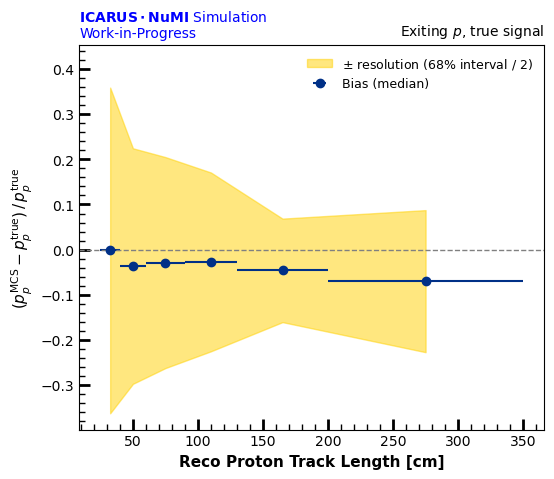

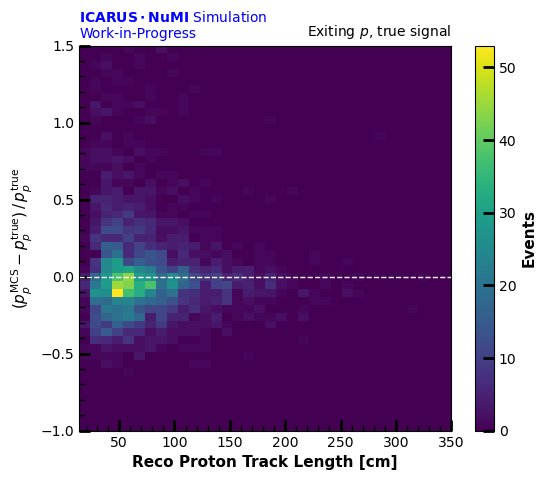


Baseline (no proton containment/length req.): dpT res = 117.7 MeV/c
             require contained p: signal retention = 0.970, dpT res = 114.7 MeV/c
   exiting p allowed, L >= 50 cm: signal retention = 0.990, dpT res = 116.6 MeV/c
   exiting p allowed, L >= 28 cm: signal retention = 0.999, dpT res = 117.6 MeV/c


In [1]:
# MCS on exiting protons -- reviewer questions (London, 4 in a row)
#
#   1. Contained vs. exiting proton residuals, with numbers for each.
#   2. Minimum track length for MCS on exiting protons. (SPINE imposes no
#      explicit minimum: mcs_ke runs whenever >= 1 scattering angle exists,
#      i.e. the track spans more than one 14 cm segment. The fiducial margins
#      [25,25,30/50] cm guarantee exiting tracks span >= ~25 cm.)
#   3. Exiting-proton momentum resolution in bins of reco track length.
#   4. Fraction of events with exiting (leading) protons; effect of requiring
#      proton containment, or a 50 cm minimum length, on dpT resolution.
#
# Same conventions as the muon study above: true signal = categories
# {0,1,3,4}; bias = median of fractional residual; resolution = half the
# central 68% interval; dpT resolution un-normalized (reco - true).

import os
import uproot
import numpy as np
import matplotlib.pyplot as plt

DATA_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)

NAVY, GOLD, RED, GREEN = "#003087", "#FFD100", "#CC0000", "#2E8B57"

t = uproot.open(DATA_FILE)["events/full/selected"]
arr = t.arrays(
    [
        "true_category",
        "reco_leading_proton_containment",
        "reco_leading_proton_length",
        "reco_leading_proton_momentum",
        "true_leading_proton_momentum",
        "reco_leading_proton_mcs_ke",
        "reco_dpT_lp",
        "true_dpT_lp_genie",
    ],
    library="np",
)

# ---------------------------------------------------------------
# 1) + 4a) Contained vs. exiting counts and residuals
# ---------------------------------------------------------------
n_all = len(arr["true_category"])
exiting = arr["reco_leading_proton_containment"] == 0
print(f"All selected entries: {n_all}")
print(f"Exiting leading proton (all selected): {exiting.sum()} "
      f"({100 * exiting.sum() / n_all:.2f}%)")

signal = np.isin(arr["true_category"], [0, 1, 3, 4])
valid = arr["true_leading_proton_momentum"] > 0
m_sig = signal & valid
print(f"True-signal selected w/ valid truth: {m_sig.sum()}")
print(f"  contained leading p: {(m_sig & ~exiting).sum()}, "
      f"exiting leading p: {(m_sig & exiting).sum()} "
      f"({100 * (m_sig & exiting).sum() / m_sig.sum():.2f}%)")

for name, mask in [("contained", m_sig & ~exiting), ("exiting", m_sig & exiting)]:
    r = (arr["reco_leading_proton_momentum"][mask]
         - arr["true_leading_proton_momentum"][mask]) \
        / arr["true_leading_proton_momentum"][mask]
    q16, q50, q84 = np.percentile(r, [15.865, 50.0, 84.135])
    print(f"  {name:>9} leading p: N={mask.sum()}, bias(median)={q50:.3f}, "
          f"res(68%/2)={0.5 * (q84 - q16):.3f}")

# ---------------------------------------------------------------
# 2) Track length floor and MCS MLE bound pile-up for exiting protons
# ---------------------------------------------------------------
m = m_sig & exiting
L = arr["reco_leading_proton_length"][m]
mcs = arr["reco_leading_proton_mcs_ke"][m]
r = (arr["reco_leading_proton_momentum"][m]
     - arr["true_leading_proton_momentum"][m]) \
    / arr["true_leading_proton_momentum"][m]
print(f"\nExiting-p reco length percentiles [0,1,5,25,50,75,95,99,100]:")
print(f"  {np.percentile(L, [0, 1, 5, 25, 50, 75, 95, 99, 100]).round(1)}")
print(f"Below 14 cm (no MCS possible): {(L < 14).sum()}; "
      f"below 28 cm (single partial second segment): {(L < 28).sum()} "
      f"({100 * (L < 28).sum() / len(L):.2f}%)")
print(f"MCS KE at MLE lower bound (10 MeV): {(mcs == 10.0).sum()}; "
      f"at upper bound (100 GeV): {(mcs == 100000.0).sum()} "
      f"({100 * (mcs == 100000.0).sum() / len(mcs):.2f}%)")

# ---------------------------------------------------------------
# 3) Bias/resolution vs. reco track length for exiting protons
# ---------------------------------------------------------------
# The 14-25 cm bin is excluded from the plot: with a single (partial) second
# segment the fit is unconstrained (res ~ 40 in that bin, 47 events).
edges_tab = np.array([14., 25., 40., 60., 90., 130., 200., 350.])
print(f"\nExiting-p bias/res vs reco track length:")
print(f"{'bin [cm]':>14} {'N':>6} {'bias':>8} {'res':>8}")
for lo, hi in zip(edges_tab[:-1], edges_tab[1:]):
    s = (L >= lo) & (L < hi)
    if s.sum() < 20:
        print(f"{lo:>6.0f}-{hi:<7.0f} {s.sum():>6d}      n/a      n/a")
        continue
    q16, q50, q84 = np.percentile(r[s], [15.865, 50.0, 84.135])
    print(f"{lo:>6.0f}-{hi:<7.0f} {s.sum():>6d} {q50:>8.3f} {0.5 * (q84 - q16):>8.3f}")

edges = np.array([25., 40., 60., 90., 130., 200., 350.])
centers = 0.5 * (edges[:-1] + edges[1:])
half_widths = 0.5 * np.diff(edges)
bias, res = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    s = (L >= lo) & (L < hi)
    q16, q50, q84 = np.percentile(r[s], [15.865, 50.0, 84.135])
    bias.append(q50)
    res.append(0.5 * (q84 - q16))
bias, res = np.array(bias), np.array(res)

OUT_DIR = os.getcwd()
os.makedirs(os.path.join(OUT_DIR, "pdf"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "jpeg"), exist_ok=True)

def apply_icarus_style(ax, xlabel, ylabel, right_label):
    ax.set_xlabel(xlabel, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2,
                   direction="in")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily("sans-serif")
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
            r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\nWork-in-Progress",
            fontsize=10, color="blue", verticalalignment="bottom",
            fontfamily="sans-serif")
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02, right_label,
            fontsize=10, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

fig, ax = plt.subplots(figsize=(6, 5))
ax.fill_between(centers, bias - res, bias + res, color=GOLD, alpha=0.5,
                label=r"$\pm$ resolution (68% interval / 2)")
ax.errorbar(centers, bias, xerr=half_widths, fmt="o", color=NAVY,
            label="Bias (median)")
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 1.15)
ax.legend(fontsize=9, loc="upper right", framealpha=0.0, edgecolor="none")
apply_icarus_style(ax, "Reco Proton Track Length [cm]",
                   r"$(p_{p}^{\rm MCS} - p_{p}^{\rm true})\,/\,p_{p}^{\rm true}$",
                   r"Exiting $p$, true signal")
fig.savefig(os.path.join(OUT_DIR, "pdf/mcs_proton_bias_resolution_vs_length.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUT_DIR, "jpeg/mcs_proton_bias_resolution_vs_length.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
H, xe, ye = np.histogram2d(L, r, bins=[np.linspace(14, 350, 35),
                                       np.linspace(-1.0, 1.5, 50)])
pc = ax.pcolormesh(xe, ye, H.T, cmap="viridis")
cbar = fig.colorbar(pc, ax=ax)
cbar.set_label("Events", fontsize=11, fontweight="bold", fontfamily="sans-serif")
cbar.ax.tick_params(labelsize=10, size=8, width=2, direction="in")
ax.axhline(0.0, color="white", ls="--", lw=1)
apply_icarus_style(ax, "Reco Proton Track Length [cm]",
                   r"$(p_{p}^{\rm MCS} - p_{p}^{\rm true})\,/\,p_{p}^{\rm true}$",
                   r"Exiting $p$, true signal")
fig.savefig(os.path.join(OUT_DIR, "pdf/mcs_proton_residual_vs_length_2d.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUT_DIR, "jpeg/mcs_proton_residual_vs_length_2d.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()

# ---------------------------------------------------------------
# 4b) Alternative selections: proton containment or minimum length
# ---------------------------------------------------------------
dpt_r = arr["reco_dpT_lp"][m_sig]
dpt_t = arr["true_dpT_lp_genie"][m_sig]
len_p = arr["reco_leading_proton_length"][m_sig]
ex = exiting[m_sig]

def dpt_res(keep):
    d = dpt_r[keep] - dpt_t[keep]
    d16, d84 = np.percentile(d, [15.865, 84.135])
    return 0.5 * (d84 - d16)

print(f"\nBaseline (no proton containment/length req.): "
      f"dpT res = {dpt_res(np.ones(m_sig.sum(), bool)):.1f} MeV/c")
for lab, keep in [("require contained p", ~ex),
                  ("exiting p allowed, L >= 50 cm", ~ex | (len_p >= 50)),
                  ("exiting p allowed, L >= 28 cm", ~ex | (len_p >= 28))]:
    print(f"  {lab:>30}: signal retention = {keep.sum() / m_sig.sum():.3f}, "
          f"dpT res = {dpt_res(keep):.1f} MeV/c")
